In [ ]:
from google.colab import files
import os

print("Please upload 'earthquake_1995-2023 lab 1 DAV.csv':")
uploaded = files.upload()
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')

Please upload 'earthquake_1995-2023 lab 1 DAV.csv':


Saving earthquake_1995-2023 lab 1 DAV.csv to earthquake_1995-2023 lab 1 DAV.csv
User uploaded file "earthquake_1995-2023 lab 1 DAV.csv"


In [ ]:
import pandas as pd
df="earthquake_1995-2023 lab 1 DAV.csv"

In [ ]:
# Correctly load the CSV into a DataFrame
df = pd.read_csv('earthquake_1995-2023 lab 1 DAV.csv')
display(df.head())

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


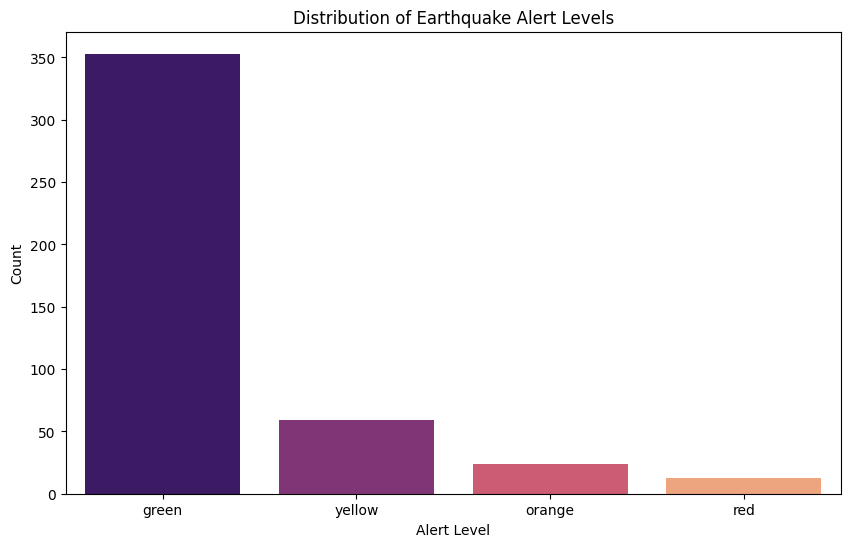

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for the 'alert' levels
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='alert', hue='alert', palette='magma', legend=False)
plt.title('Distribution of Earthquake Alert Levels')
plt.xlabel('Alert Level')
plt.ylabel('Count')
plt.show()

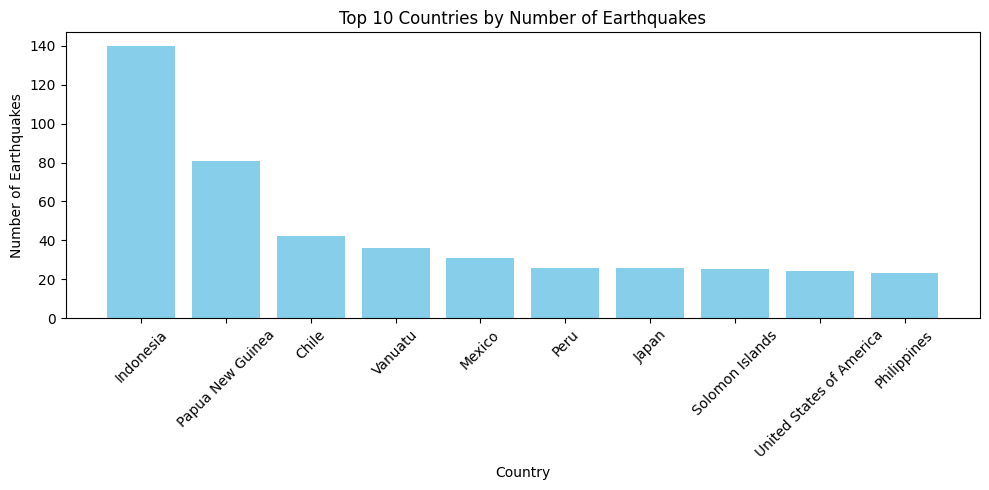

In [ ]:
import matplotlib.pyplot as plt

# The DataFrame 'df' is already loaded from 'earthquake_1995-2023 lab 1 DAV.csv'
# Calculate the top 10 countries by earthquake count
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(country_counts.index, country_counts.values, color='skyblue')

plt.title('Top 10 Countries by Number of Earthquakes')
plt.xlabel('Country')
plt.ylabel('Number of Earthquakes')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

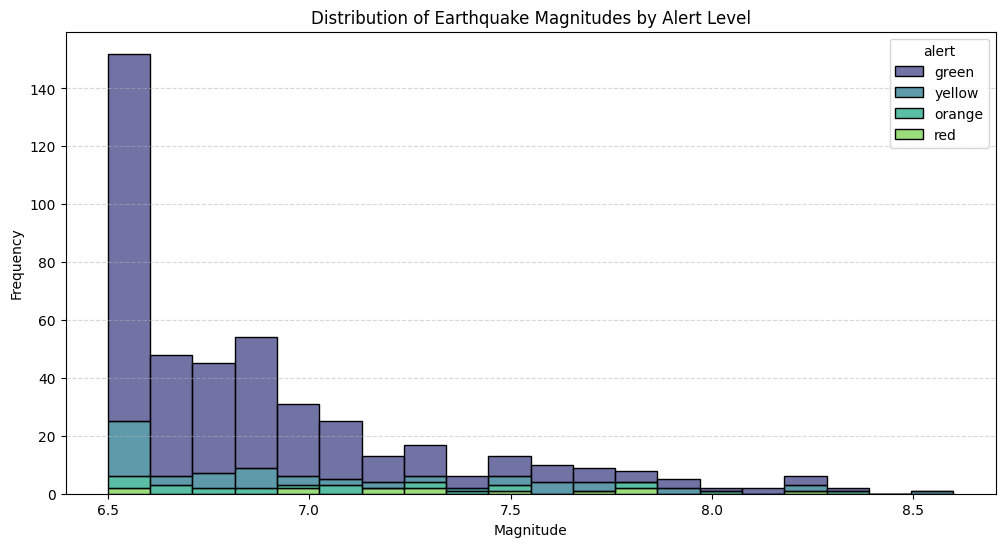

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='magnitude', hue='alert', multiple='stack', palette='viridis', bins=20)

plt.title('Distribution of Earthquake Magnitudes by Alert Level')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

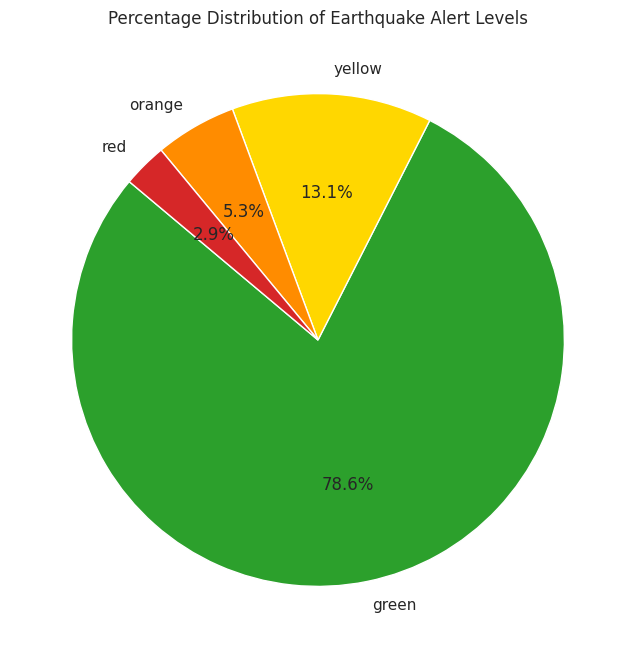

In [ ]:
import matplotlib.pyplot as plt


alert_counts = df['alert'].value_counts()

labels = alert_counts.index
colors = ['#2ca02c', 'gold', 'darkorange', '#d62728']

plt.figure(figsize=(8, 8))
plt.pie(
    alert_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
        colors=colors[0:len(labels)],

    wedgeprops={'edgecolor': 'white'}
)

plt.title('Percentage Distribution of Earthquake Alert Levels')
plt.show()

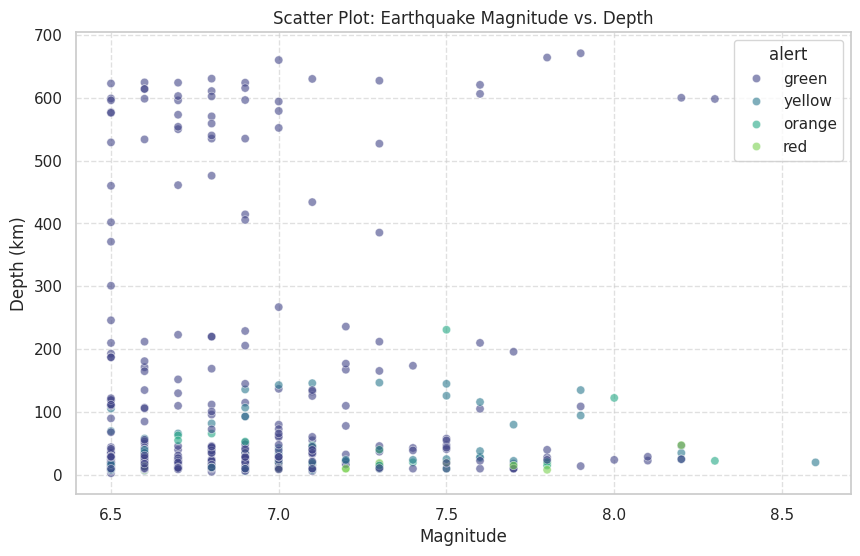

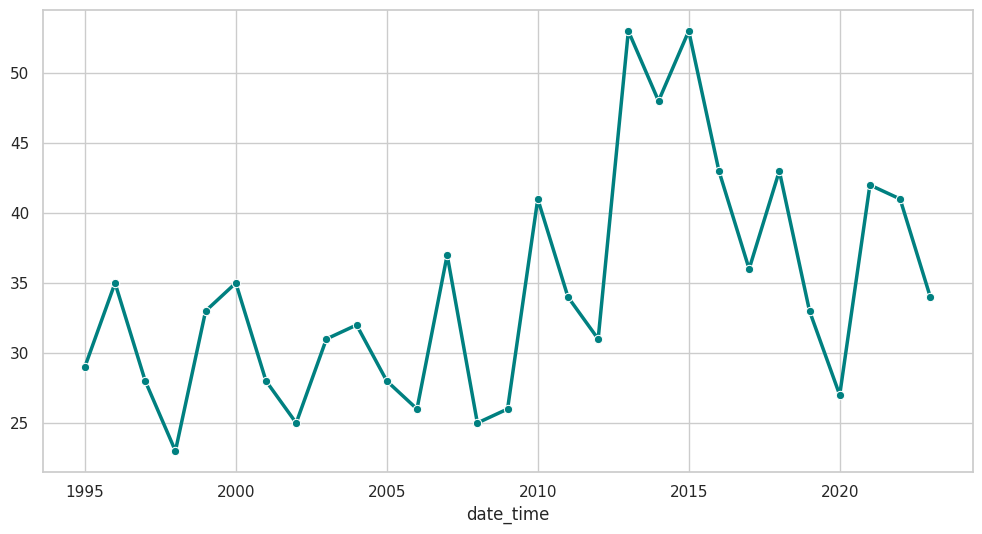

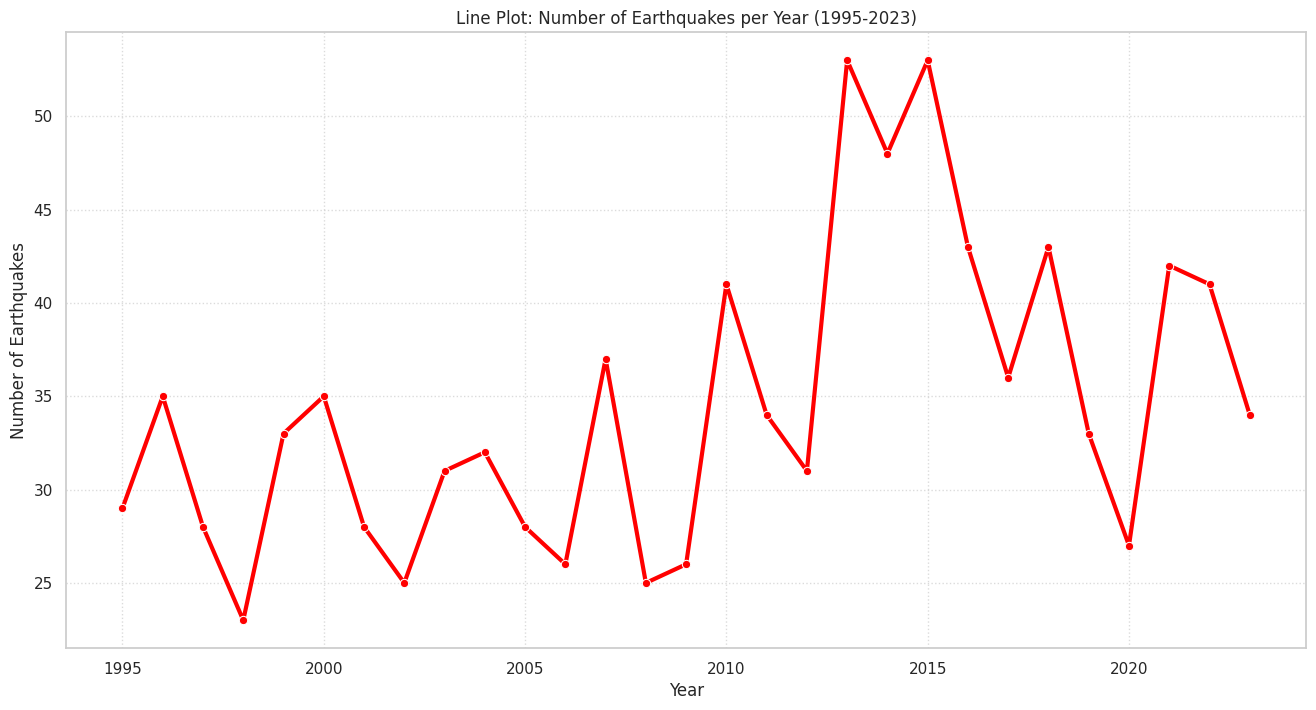

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='magnitude', y='depth', hue='alert', palette='viridis', alpha=0.6)
plt.title('Scatter Plot: Earthquake Magnitude vs. Depth')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
yearly_trends = df['date_time'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker='o', color='teal', linewidth=2.5)
plt.figure(figsize=(16, 8))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker='o', color='red', linewidth=3.0)
plt.title('Line Plot: Number of Earthquakes per Year (1995-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

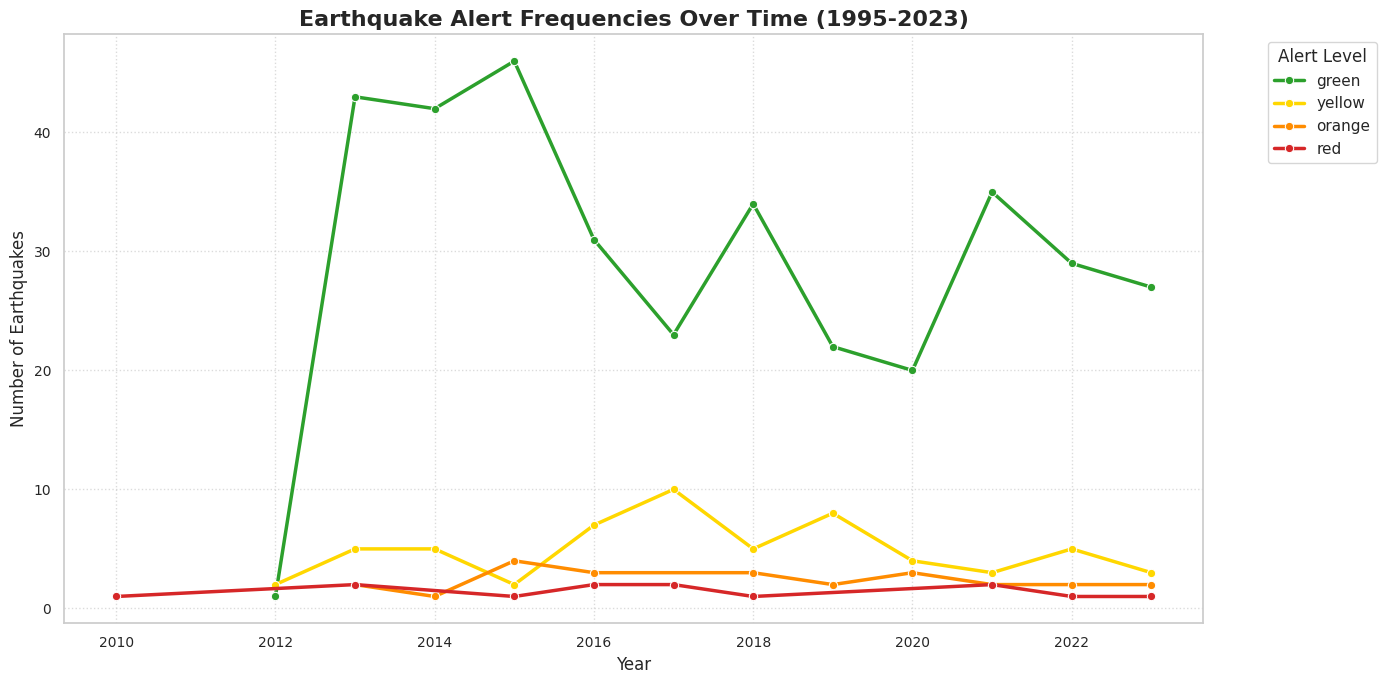

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Corrected file name based on the uploaded file
file_path = 'earthquake_1995-2023 lab 1 DAV.csv'
df = pd.read_csv(file_path)

df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', errors='coerce')
df['Year'] = df['date_time'].dt.year

df_alerts = df.dropna(subset=['alert', 'Year'])
yearly_counts = df_alerts.groupby(['Year', 'alert']).size().reset_index(name='Count')

color_mapping = {
    'green': '#2ca02c',
    'yellow': 'gold',
    'orange': 'darkorange',
    'red': '#d62728'
}

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=yearly_counts,
    x='Year',
    y='Count',
    hue='alert',
    palette=color_mapping,
    hue_order=['green', 'yellow', 'orange', 'red'],
    linewidth=2.5,
    marker='o',
    markersize=6
)

plt.title('Earthquake Alert Frequencies Over Time (1995-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Earthquakes', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.legend(title='Alert Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'earthquake_1995-2023.csv'
df = pd.read_csv(file_path)


df_alerts = df.dropna(subset=['alert', 'longitude', 'latitude'])


color_mapping = {
    'green': '#2ca02c',
    'yellow': 'gold',
    'orange': 'darkorange',
    'red': '#d62728'
}

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_alerts,
    x='longitude',
    y='latitude',
    hue='alert',
    palette=color_mapping,
    hue_order=['green', 'yellow', 'orange', 'red'],
    size='magnitude',
    sizes=(20, 300),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3
)


plt.title('Global Earthquake Locations by Alert Level (1995-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Alert / Magnitude')
plt.tight_layout()


plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'earthquake_1995-2023.csv'